In [1]:
# exercise 4 Task 1
import numpy as np

matrix = np.ones((5, 5), dtype=int)
matrix[1:-1, 1:-1] = 0

print(matrix)

[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]


In [2]:
# Exercise 4 Task 2
import numpy as np

np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized_data = (random_data - np.mean(random_data, axis=0)) / np.std(random_data, axis=0)

print("Means:", np.mean(normalized_data, axis=0))
print("Standard Deviations:", np.std(normalized_data, axis=0))

Means: [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Standard Deviations: [1. 1. 1.]


In [3]:
# Exercise 4 Task 3
import numpy as np

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients (theta_hat):")
print(theta_hat)

print("\nTrue coefficients (true_theta):")
print(true_theta)

print("\nDifference:")
print(theta_hat - true_theta)

Estimated coefficients (theta_hat):
[ 2.51723721 -1.19783796  3.72399266]

True coefficients (true_theta):
[ 2.5 -1.2  3.7]

Difference:
[0.01723721 0.00216204 0.02399266]


In [5]:
# Exercise 5 Task 1

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


print("Dataset Info:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

First 5 rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2     

In [8]:
# Exercise 5 task 2

avg_scores = df.groupby('major')['exam_score'].mean()

print("Average Exam Score by Major:")
print(avg_scores)

best_major = avg_scores.idxmax()
highest_score = avg_scores.max()

print(f"\nMajor with highest average exam score: {best_major}")
print(f"Average score: {highest_score:.2f}")

correlation = df['hours_studied'].corr(df['exam_score'])

print(f"\nCorrelation between hours studied and exam score: {correlation:.4f}")

conditions = [
    df['exam_score'] > 90,
    (df['exam_score'] >= 80) & (df['exam_score'] <= 90),
    (df['exam_score'] >= 70) & (df['exam_score'] < 80),
    df['exam_score'] < 70
]

categories = [
    'Excellent',
    'Good',
    'Average',
    'Needs Improvement'
]

df['performance'] = np.select(
    conditions,
    categories,
    default='Needs Improvement'
)

print("\nPerformance Categories:")
print(df[['exam_score', 'performance']].head())

Average Exam Score by Major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with highest average exam score: CS
Average score: 76.43

Correlation between hours studied and exam score: -0.0560

Performance Categories:
   exam_score        performance
0   68.199753  Needs Improvement
1   77.322537            Average
2   77.930725            Average
3   67.856486  Needs Improvement
4   93.657745          Excellent


In [9]:
# Exercise 5 Task 3

summary = df.groupby(['major', 'year']).agg(
    number_of_students=('student_id', 'count'),
    average_exam_score=('exam_score', 'mean'),
    average_hours_studied=('hours_studied', 'mean')
)

print("Summary by Major and Year:")
print(summary)


fifth_score = df['exam_score'].nlargest(5).iloc[-1]

top_students = df[df['exam_score'] >= fifth_score] \
    .sort_values('exam_score', ascending=False)

print("\nTop Students (including ties):")
print(top_students[['student_id', 'major', 'year', 'exam_score']])


pivot_table = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table: Average Exam Score")
print(pivot_table)

Summary by Major and Year:
              number_of_students  average_exam_score  average_hours_studied
major   year                                                               
Biology 1                     13           76.570059              12.677806
        2                     12           74.899613              13.426372
        3                     14           80.178476              14.486815
        4                     15           70.697689              14.253944
CS      1                     12           77.098194              13.039480
        2                      7           76.155936              13.995784
        3                      9           72.347626              15.039892
        4                     18           78.119997              16.275541
Math    1                     11           74.053167              19.001215
        2                      9           81.226714              12.345468
        3                     10           72.017537         

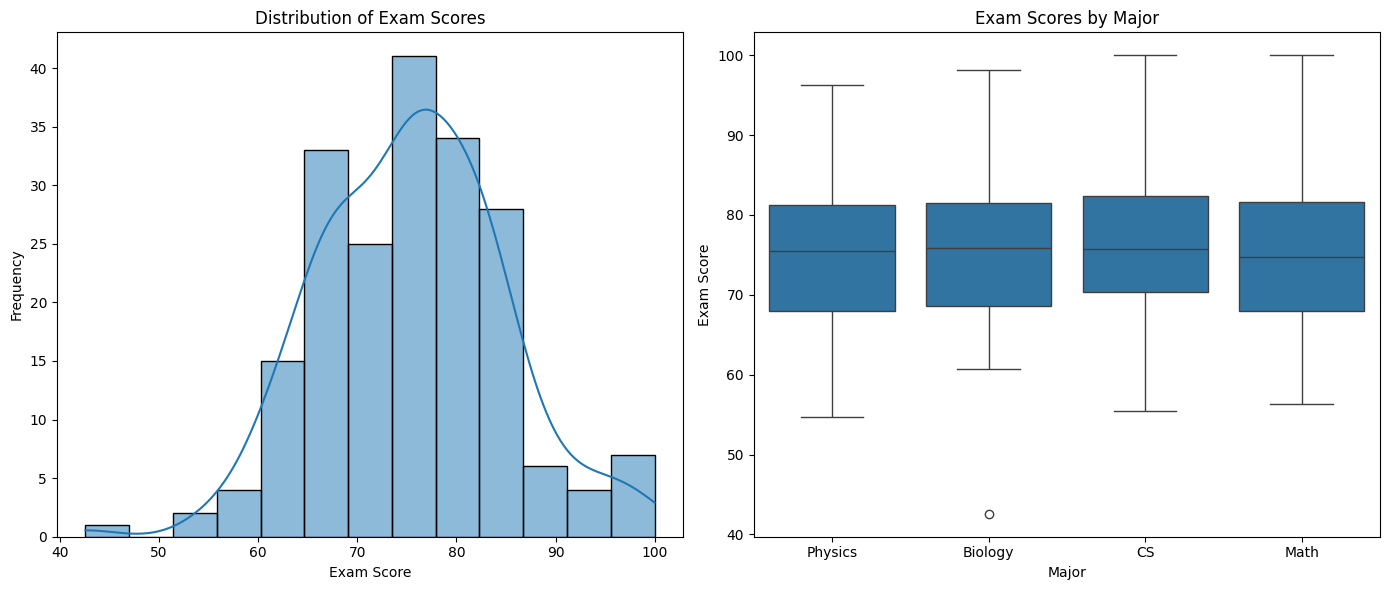

In [10]:
#Exercise 6 Task 1
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    data=df,
    x='exam_score',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')

sns.boxplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[1]
)

axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()

plt.show()

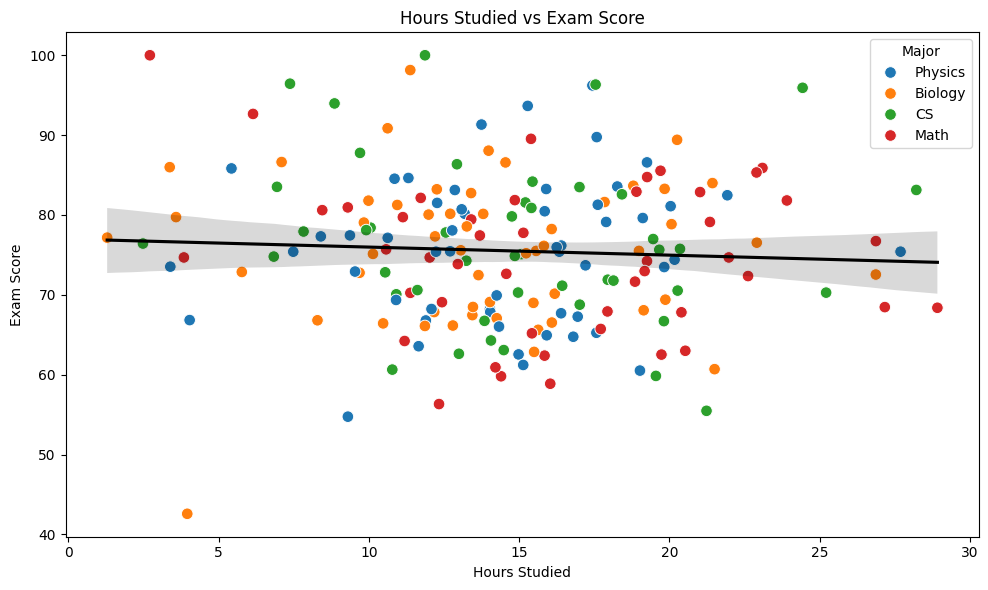

In [11]:
# Exercise 6 Task 2
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    s=70
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black'
)

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

plt.legend(title='Major')

plt.tight_layout()

plt.show()

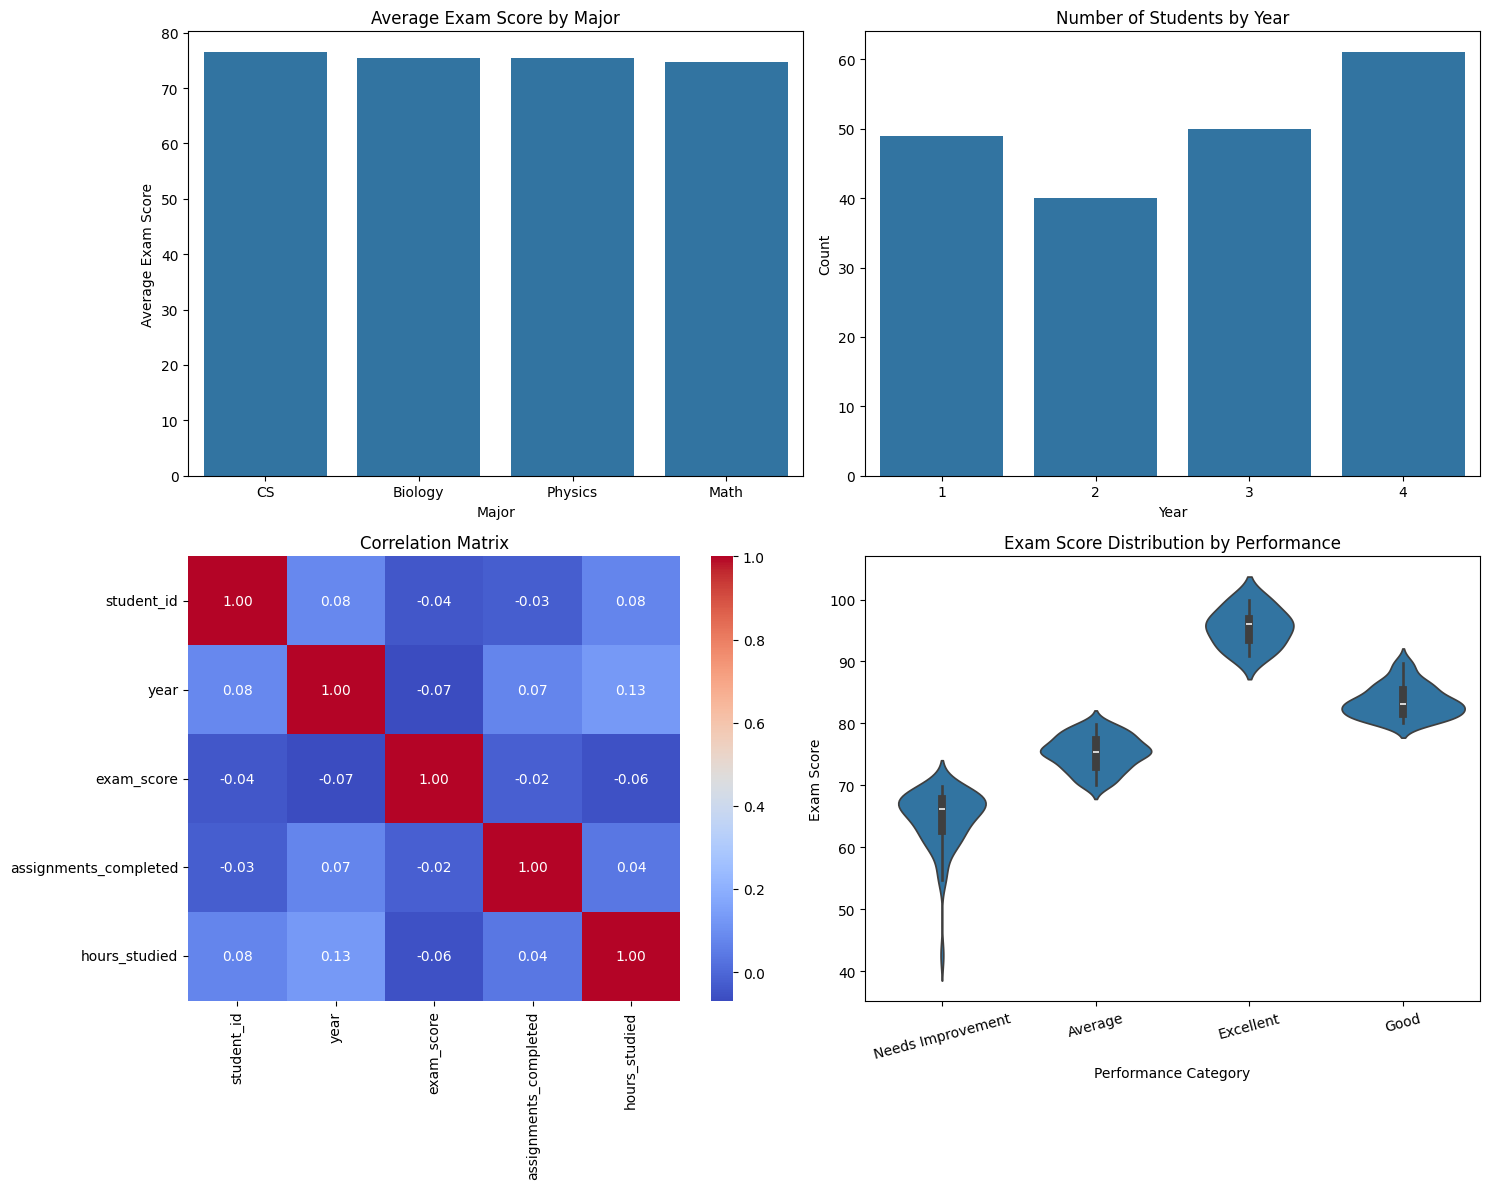

In [12]:
# Exercise 6 task 3
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

avg_scores = df.groupby('major')['exam_score'].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_scores.index,
    y=avg_scores.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Exam Score')

sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

numeric_cols = df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Correlation Matrix')

sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Exam Score Distribution by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()

plt.show()

/tmp/ipykernel_13390/2522940200.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = customers.groupby('age_group').agg(
/tmp/ipykernel_13390/2522940200.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


Age Group Summary
           number_of_customers  average_income  average_clv      total_clv
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683

Top 10% Customers by CLV
    age        income          CLV
6    38  58876.388563  1287.201143
9    40  48809.492879  1286.000108
19   41  21282.756976  1276.279663
24   38  53981.193911  1283.421714
57   64  45956.146951  1343.416638


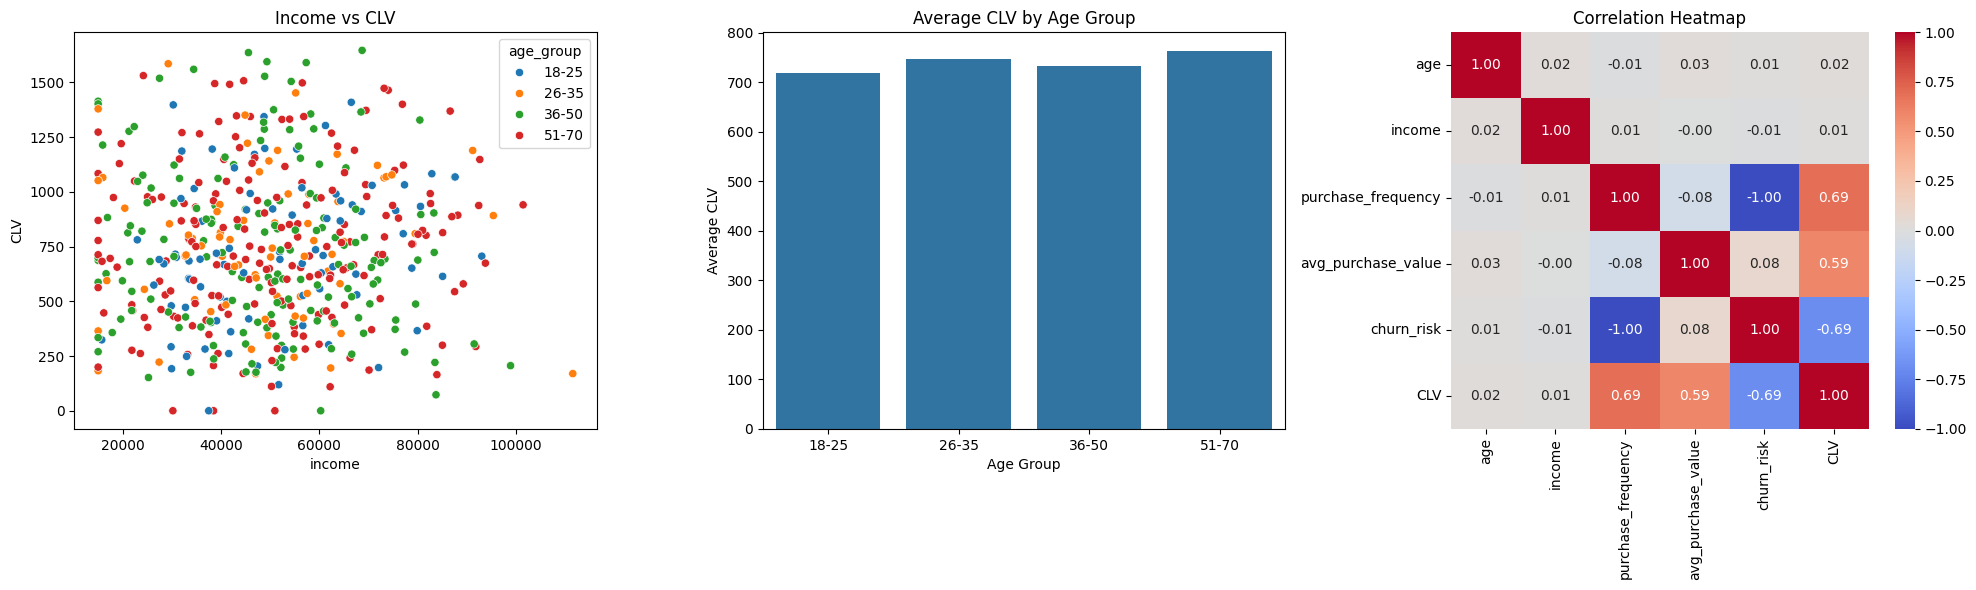

In [14]:
# Exercise 7
np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency
)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 26, 36, 51, 71],
    labels=['18-25', '26-35', '36-50', '51-70'],
    right=False
)

age_summary = customers.groupby('age_group').agg(
    number_of_customers=('age', 'count'),
    average_income=('income', 'mean'),
    average_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)

print("Age Group Summary")
print(age_summary)

threshold = customers['CLV'].quantile(0.90)

top_customers = customers[customers['CLV'] >= threshold]

print("\nTop 10% Customers by CLV")
print(top_customers[['age', 'income', 'CLV']].head())


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group',
    ax=axes[0]
)

axes[0].set_title('Income vs CLV')

avg_clv = customers.groupby('age_group')['CLV'].mean()

sns.barplot(
    x=avg_clv.index,
    y=avg_clv.values,
    ax=axes[1]
)

axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV')

corr = customers[
    ['age', 'income', 'purchase_frequency',
     'avg_purchase_value', 'churn_risk', 'CLV']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[2]
)

axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()